# **Coding Attention Mechanisms**

## The problem with modeling long sequences

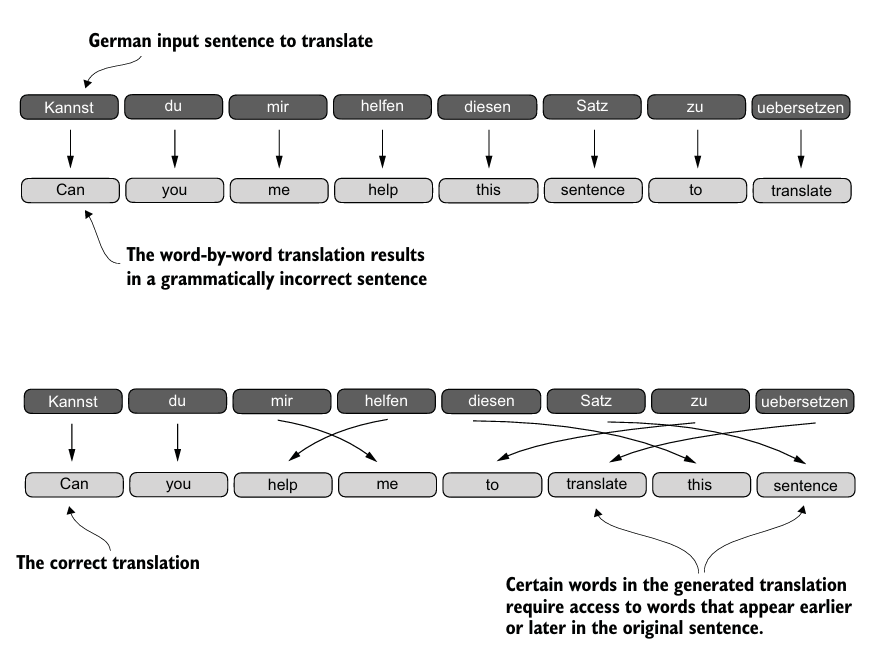

Translating a text word by word isn't feasible due to the differences in grammatical structures between the source and target languages:

Prior to the introduction of transformer models, encoder-decoder RNNs were commonly used for machine translation tasks.

In this setup, the encoder processes a sequence of tokens from the source language, using a hidden state—a kind of intermediate layer within the neural network—to generate a condensed representation of the entire input sequence:

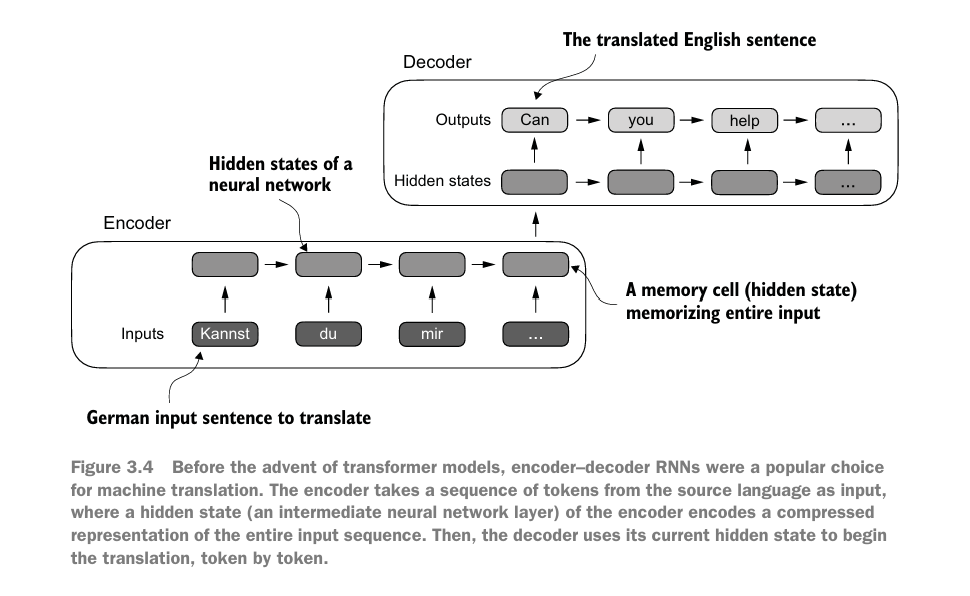

Through an attention mechanism, the text-generating decoder segment of the network is capable of selectively accessing all input tokens, implying that certain input tokens hold more significance than others in the generation of a specific output token:

Self-attention in transformers is a technique designed to enhance input representations by enabling each position in a sequence to engage with and determine the relevance of every other position within the same sequence

## Attending to different parts of the input with self-attention

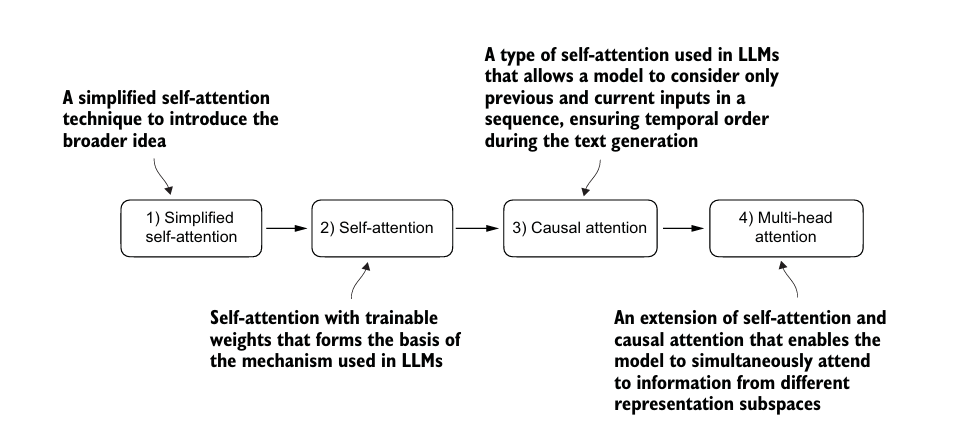

### 1) A simple self-attention mechanism without trainable weights

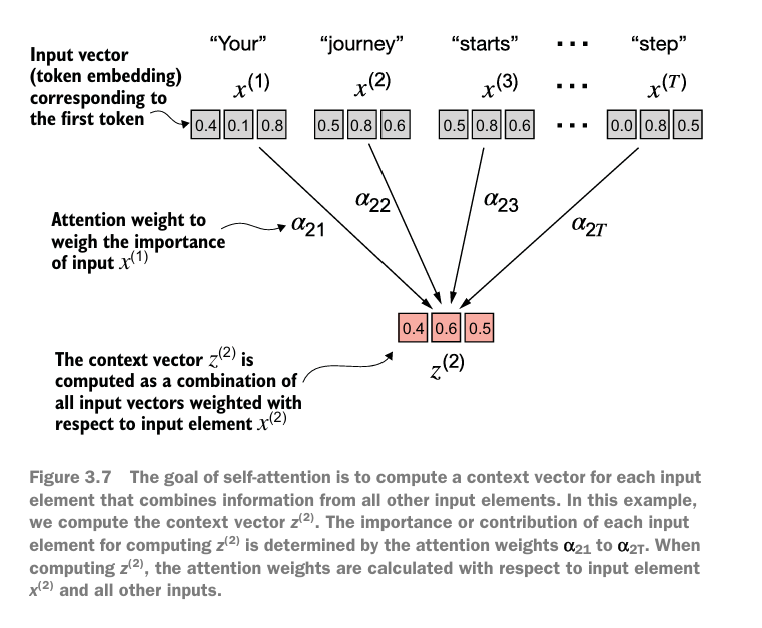

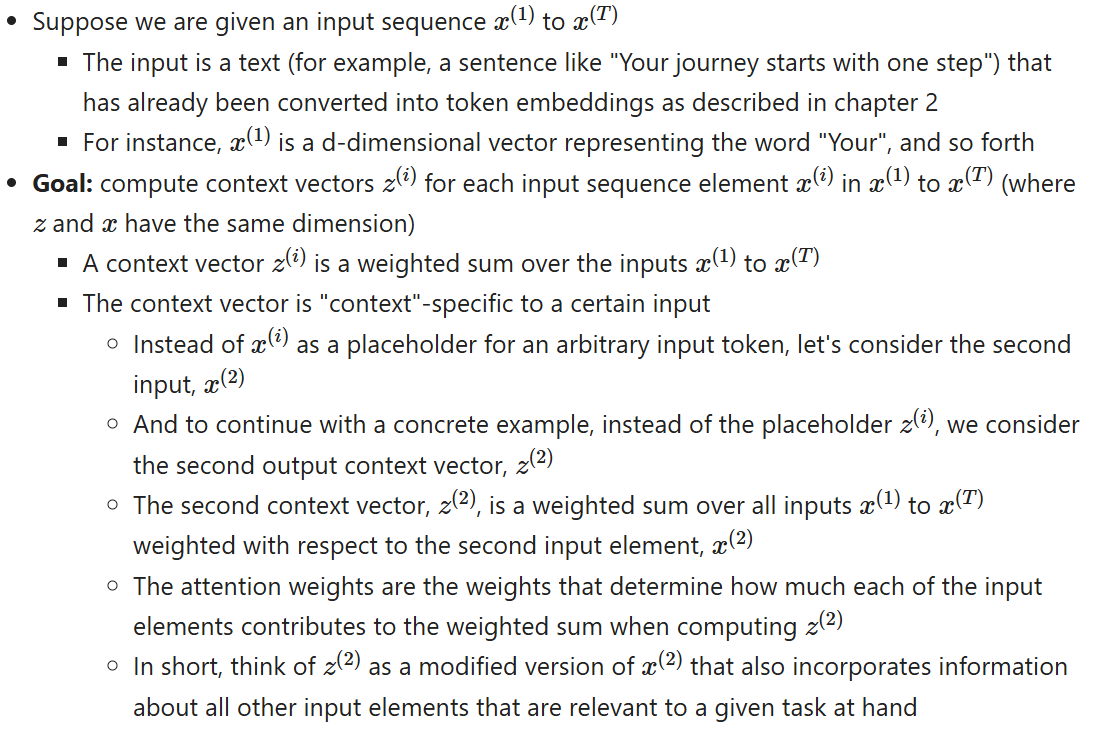

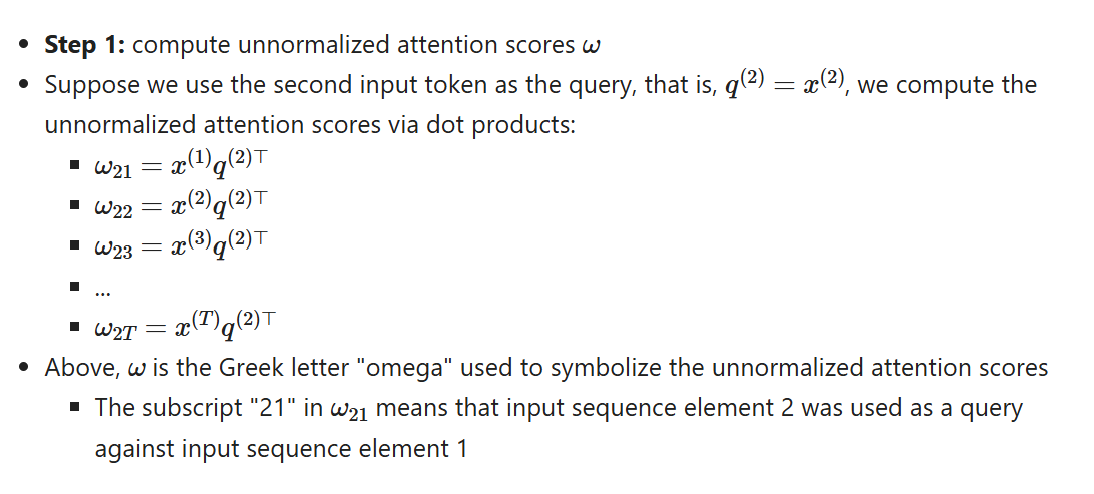

In [52]:
import torch
print(torch.__version__)

2.11.0+cpu


In [53]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your     (x^1)
     [0.55, 0.87, 0.66], # journey  (x^2)
     [0.57, 0.85, 0.64], # starts   (x^3)
     [0.22, 0.58, 0.33], # with     (x^4)
     [0.77, 0.25, 0.10], # one      (x^5)
     [0.05, 0.80, 0.55]]
)

In [54]:
query = inputs[1]

attenScores2 = torch.empty(inputs.shape[0])

for i, x in enumerate(inputs):
  attenScores2[i] = torch.dot(x, query)

print(attenScores2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [55]:
res = 0
for i, element in enumerate(inputs[2]):
  res += inputs[2][i] * query[i]

print(res)
print(torch.dot(inputs[2], query))

tensor(1.4754)
tensor(1.4754)


Side note: a dot product is essentially a shorthand for multiplying two vectors elements-wise and summing the resulting products:

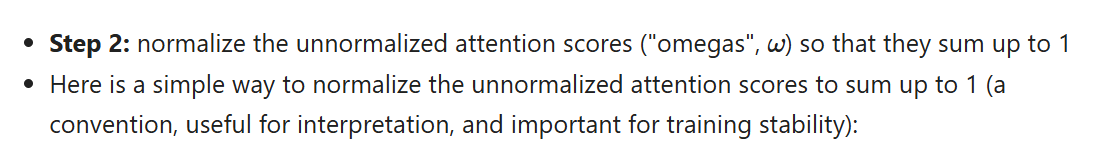

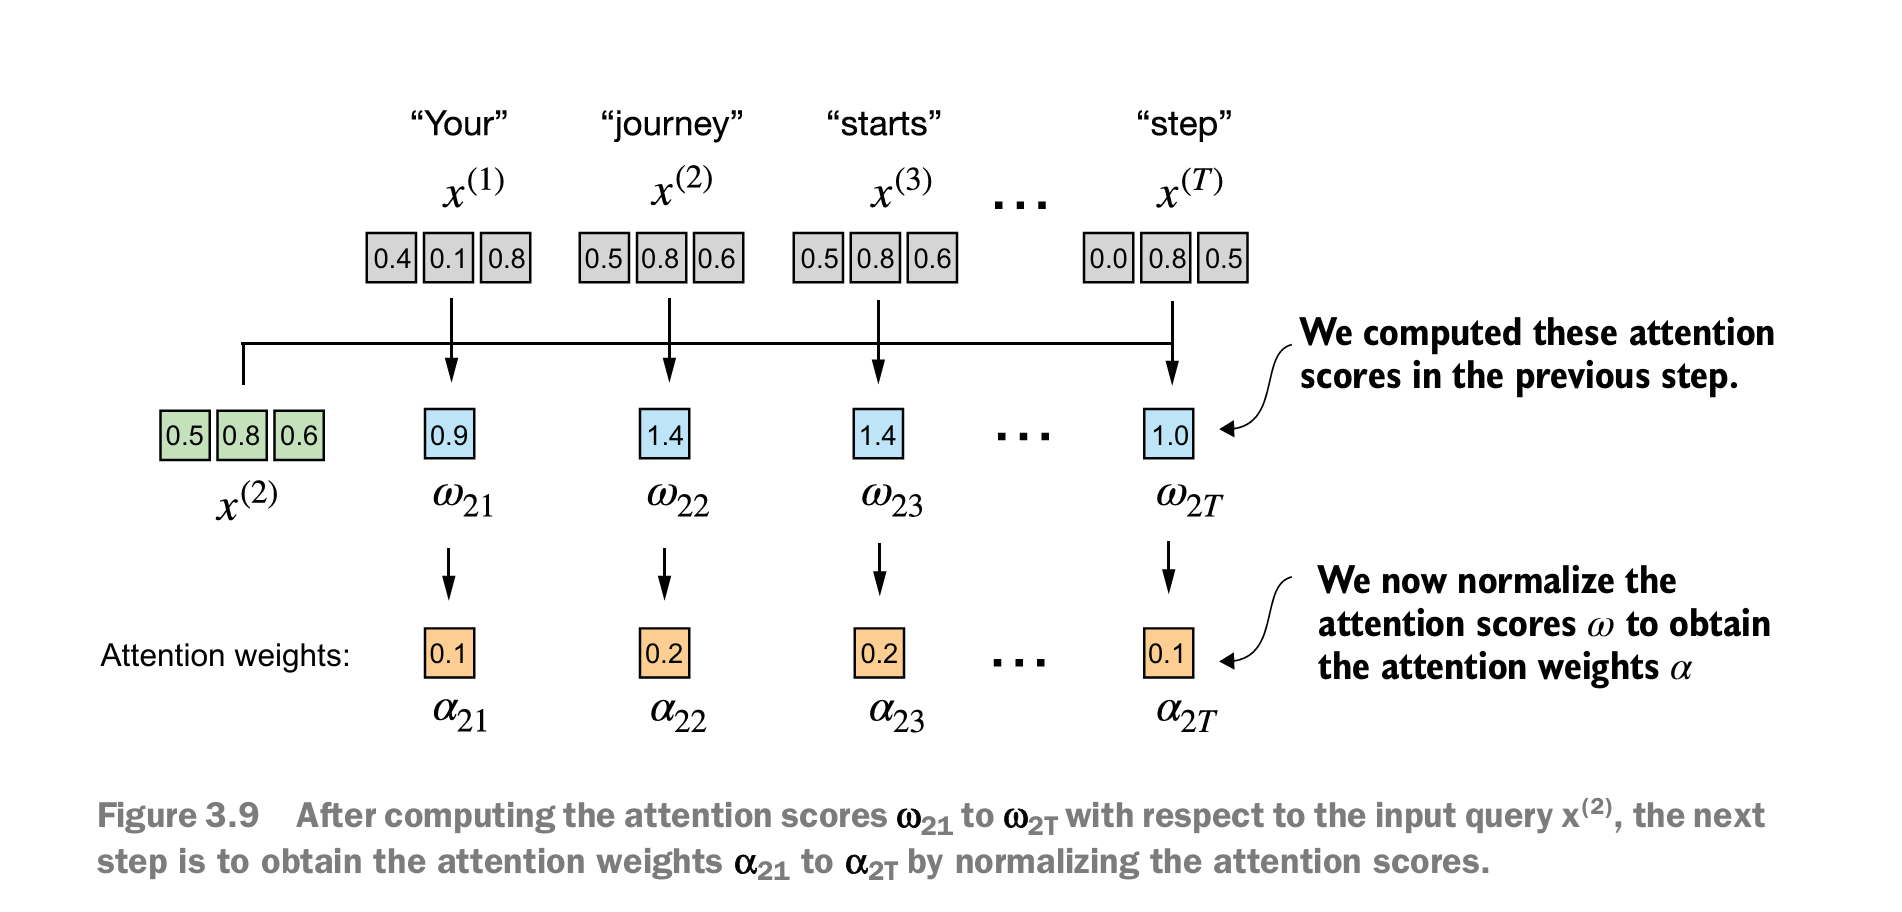

In [56]:
attenScores2

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

In [57]:
a = [1, 2 , 3, 4, 5]
c = torch.tensor(a)
b = c / c.sum()
print(b)

tensor([0.0667, 0.1333, 0.2000, 0.2667, 0.3333])


In [58]:
attenScores2normalize = attenScores2 / attenScores2.sum()
print("Attention weight: ", attenScores2normalize)
print("Sum:", attenScores2normalize.sum())

Attention weight:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


However, in practice, using the softmax function for normalization, which is better at handling extreme values and has more desirable gradient properties during training, is common and recommended.

Here's a naive implementation of a softmax function for scaling, which also normalizes the vector elements such that they sum up to 1:

In [59]:
def softmaxNaive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attenWeight2normalize = softmaxNaive(attenScores2)

print("Attention weight: ", attenWeight2normalize)
print("Sum: ", attenWeight2normalize.sum())


Attention weight:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)


The naive implementation above can suffer from numerical instability issues for large or small input values due to overflow and underflow issues

Hence, in practice, it's recommended to use the PyTorch implementation of softmax instead, which has been highly optimized for performance:

In [60]:
attnWeight2 = torch.softmax(attenScores2, dim=0)

print("Attention weight: ", attnWeight2)
print("Sum: ", attnWeight2.sum())

Attention weight:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)


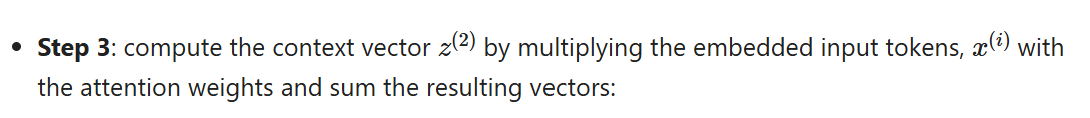

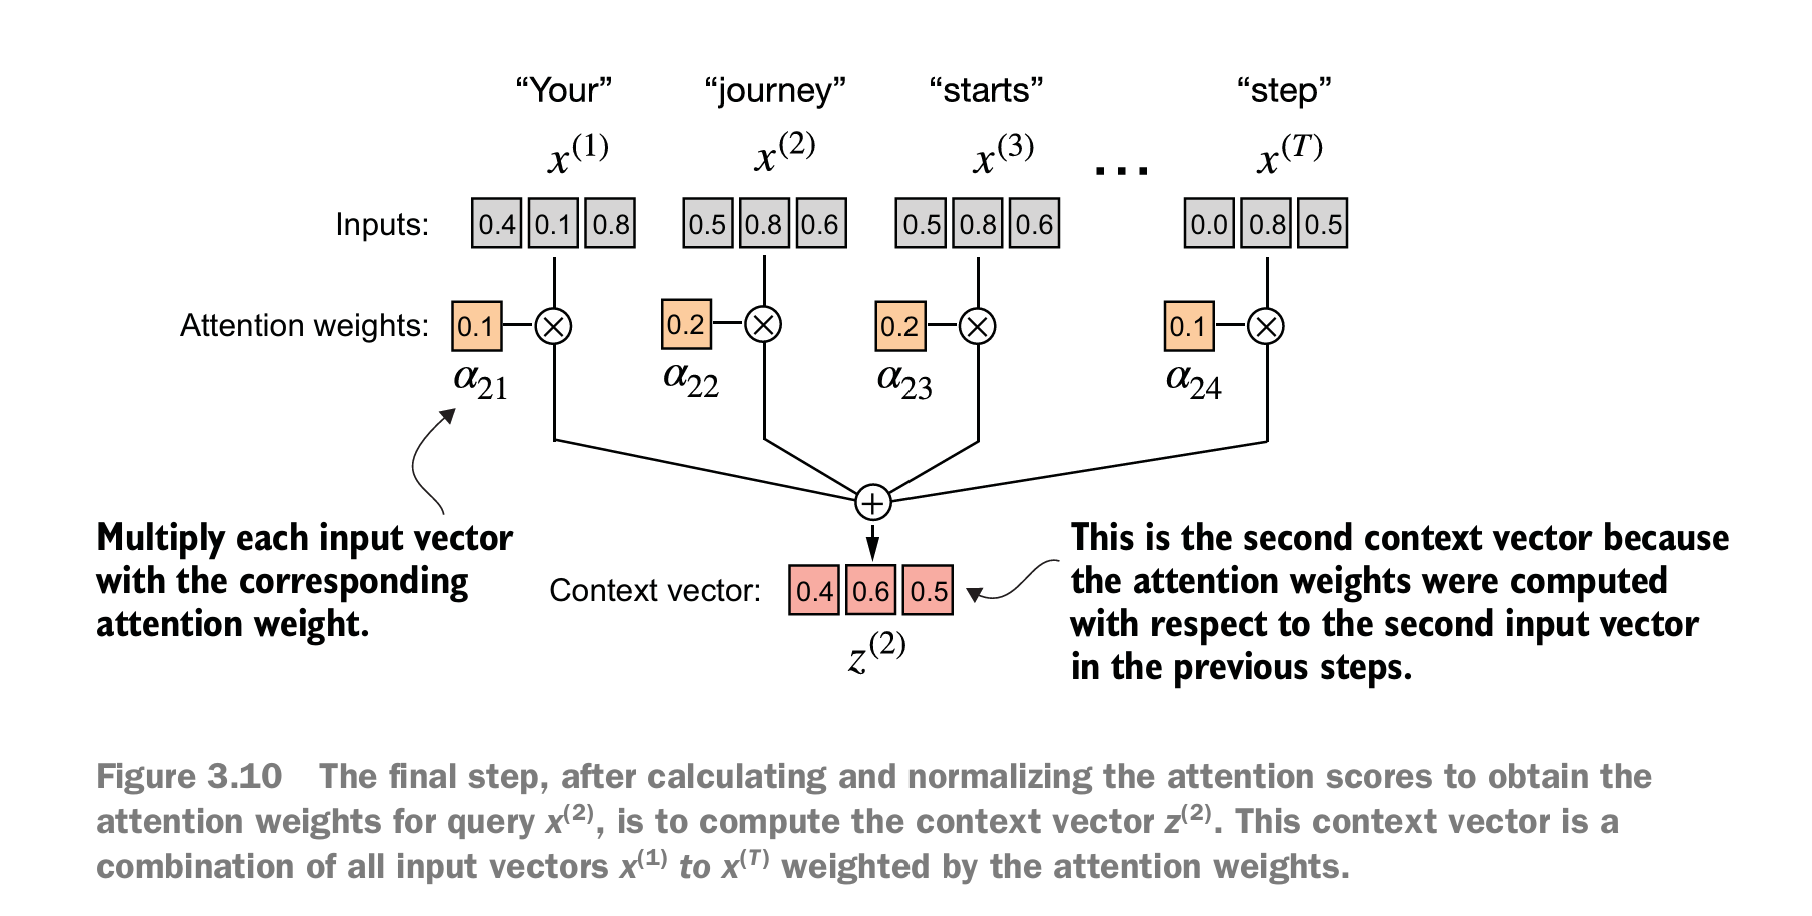

In [61]:
query = inputs[1]

contextVec2 = torch.zeros(query.shape)
for i, x in enumerate(inputs):
  contextVec2 += attnWeight2[i] * x

print(contextVec2)

tensor([0.4419, 0.6515, 0.5683])


## Computing attention weights for all input tokens

Above, we computed the attention weights and context vector for input 2 (as illustrated in the highlighted row in the figure below)

Next, we are generalizing this computation to compute all attention weights and context vectors

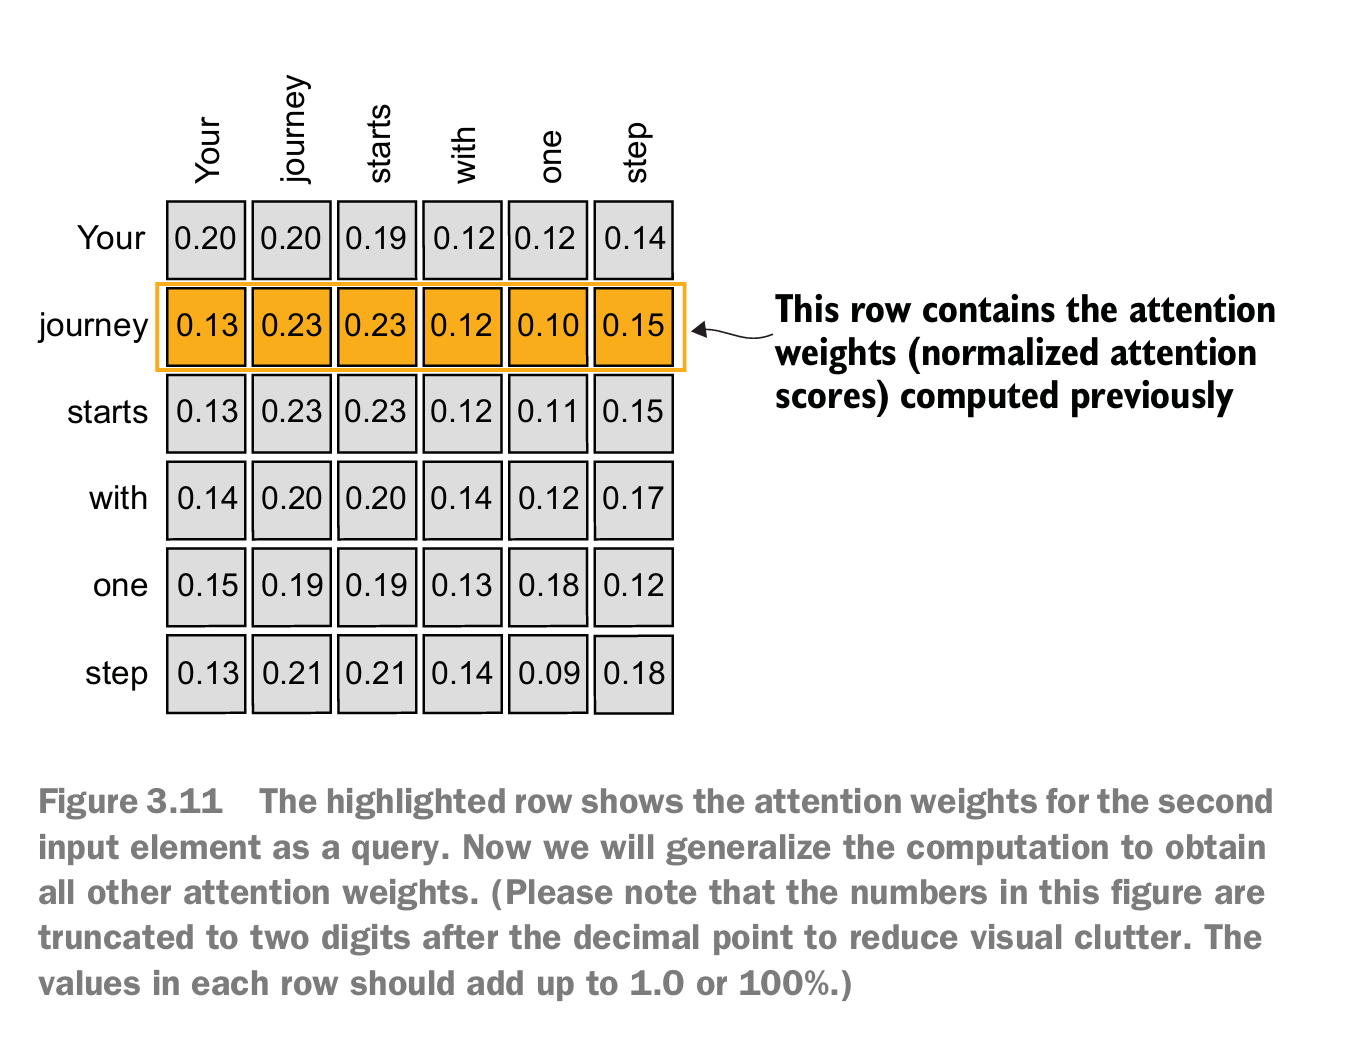

These attention weights are then utilized to generate the context vectors through a weighted summation of the inputs

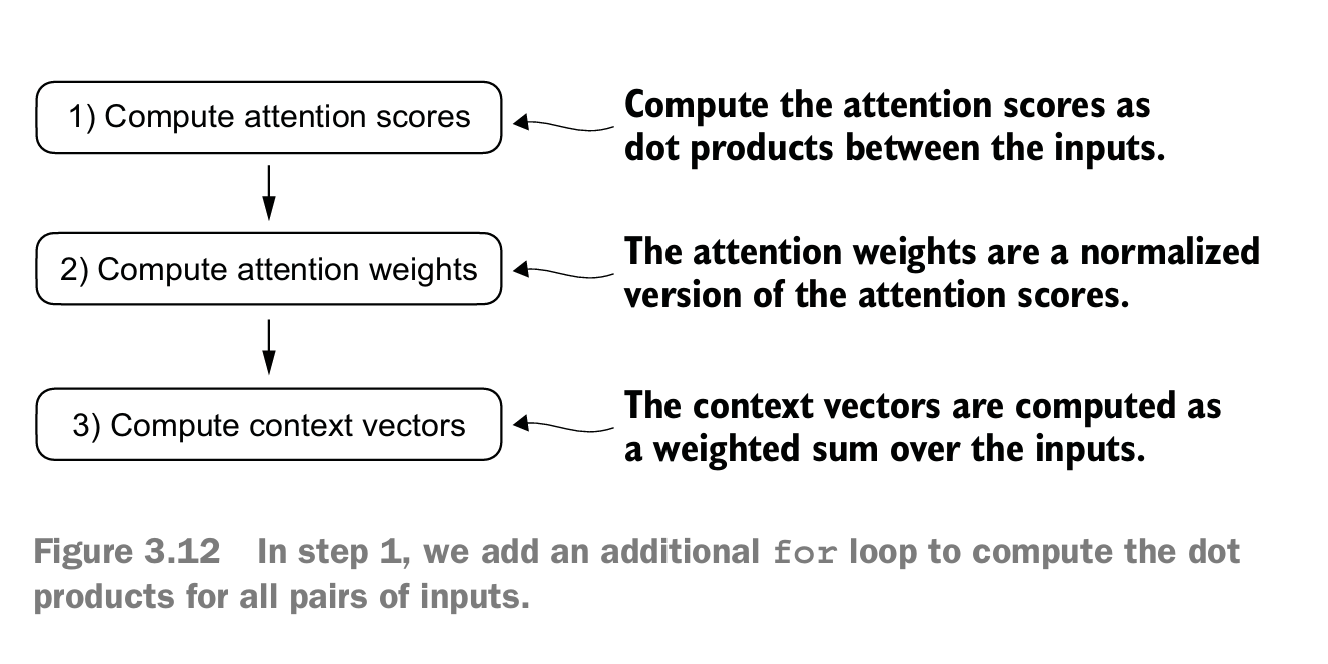

In [62]:
attentionScore = torch.empty(len(inputs), len(inputs))

In [63]:
attentionScore.shape

torch.Size([6, 6])

Apply previous step 1 to all pairwise elements to compute the unnormalized attention score matrix:

In [64]:
for i, xi in enumerate(inputs):
  for j, xj in enumerate(inputs):
    attentionScore[i, j] += torch.dot(xi, xj)


print(attentionScore)


tensor([[6.2766e+12, 9.5440e-01, 6.2766e+12, 4.7530e-01, 4.5760e-01, 6.3100e-01],
        [9.5440e-01, 1.4950e+00, 1.4754e+00, 1.6868e+00, 1.8788e+31, 1.7220e+22],
        [9.4220e-01, 1.3593e+22, 1.4570e+00, 8.2649e+20, 5.2892e+22, 1.0571e+21],
        [4.2093e+21, 1.6837e+22, 8.2960e-01, 4.9374e-01, 3.4740e-01, 6.5650e-01],
        [1.8788e+31, 7.9303e+34, 7.1602e-01, 1.8590e+34, 7.7767e+31, 7.1536e+22],
        [6.3100e-01, 2.0552e+32, 1.8755e+28, 6.5650e-01, 2.0552e+32, 1.8755e+28]])


In [65]:
attentionScore = inputs @ inputs.T
print(attentionScore)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Similar to step 2 previously, we normalize each row so that the values in each row sum to 1:

In [68]:
attentionWeight = torch.softmax(attentionScore, dim=1)
print(attentionWeight)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [69]:
print("All row sums: ", attentionWeight.sum(dim=1))

All row sums:  tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


Apply previous step 3 to compute all context vectors:

In [70]:
allContextVectors = attentionWeight @ inputs

print(allContextVectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## 2) Implementing self-attention with trainable weights

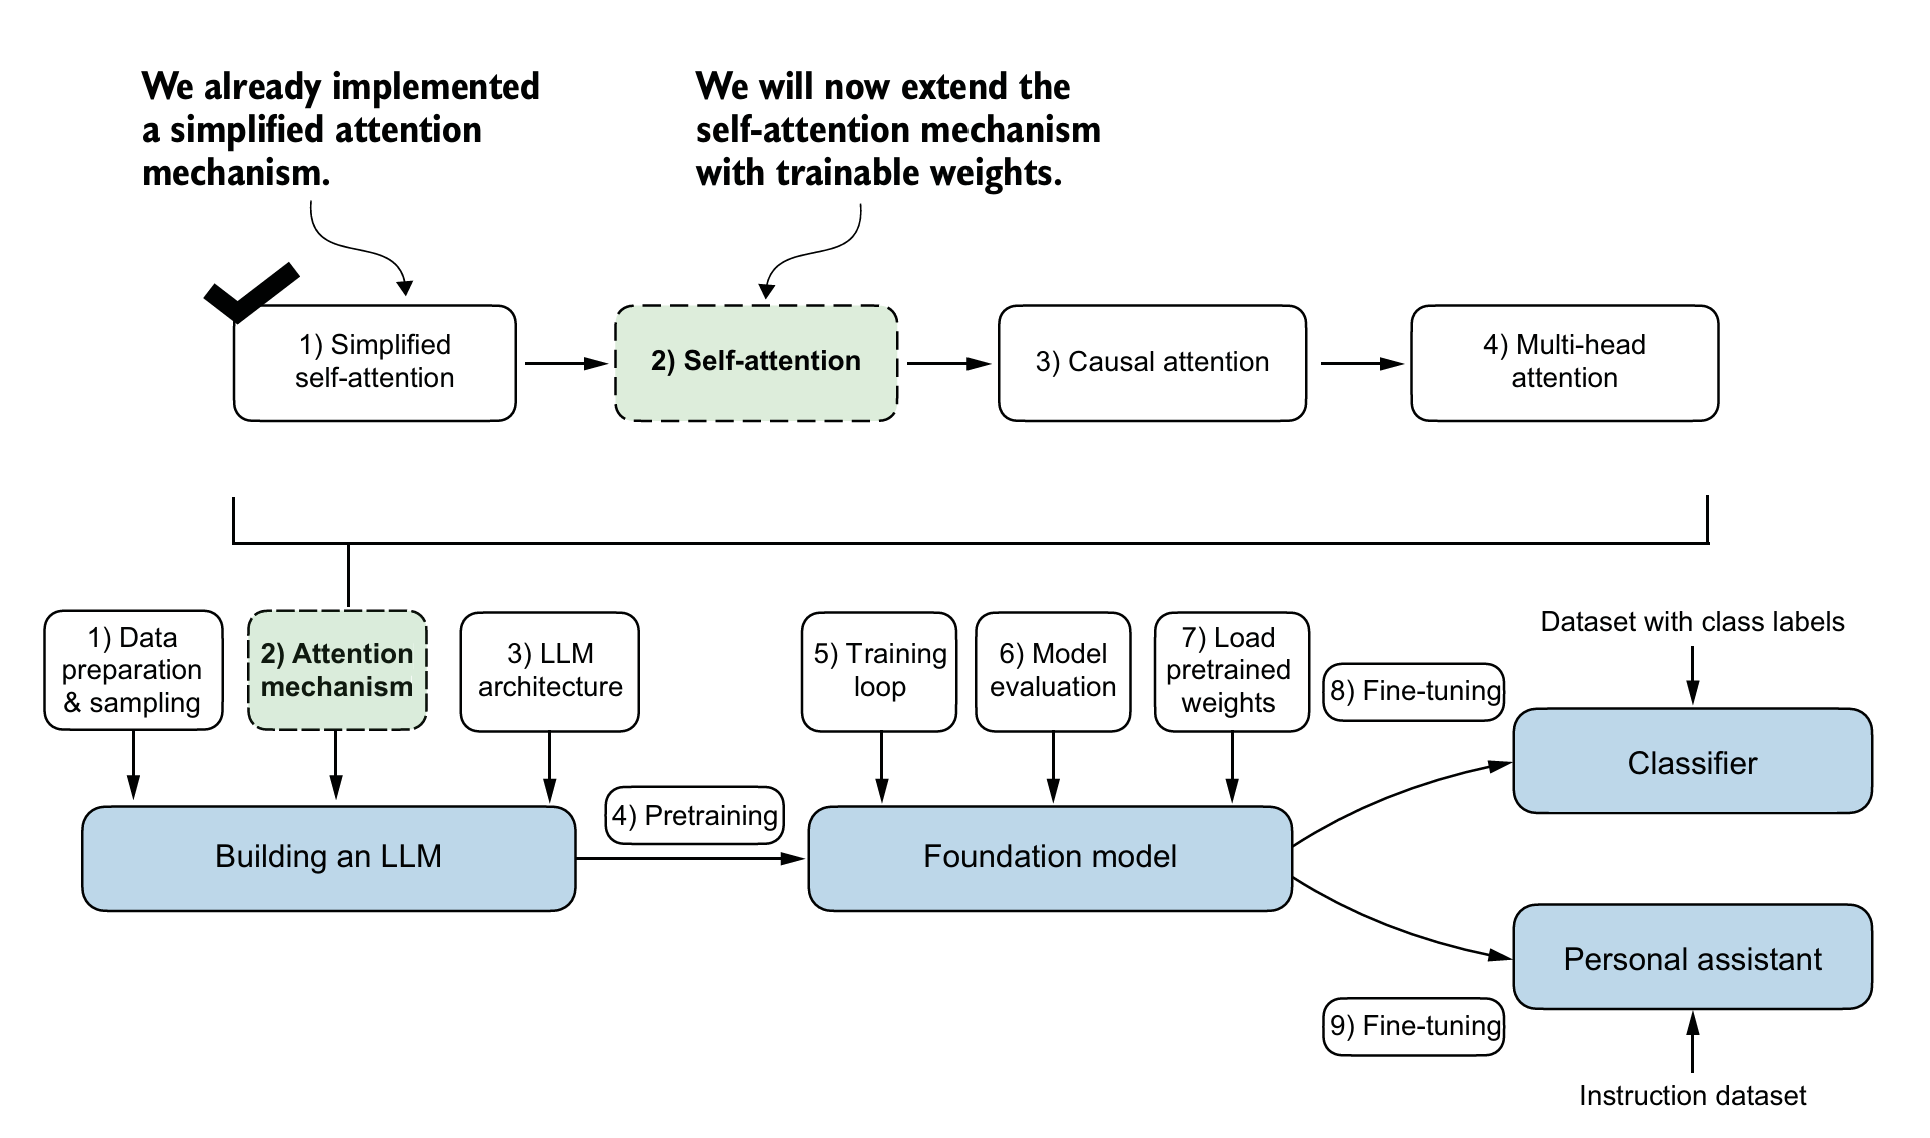

In this section, we are implementing the self-attention mechanism that is used in the original transformer architecture, the GPT models, and most other popular LLMs.

This self-attention mechanism is also called "scaled dot-product attention"

The overall idea is similar to before:

We want to compute context vectors as weighted sums over the input vectors specific to a certain input element

For the above, we need attention weights

As you will see, there are only slight differences compared to the basic attention mechanism introduced earlier:

The most notable difference is the introduction of weight matrices that are updated during model training

These trainable weight matrices are crucial so that the model (specifically, the attention module inside the model) can learn to produce "good" context vectors




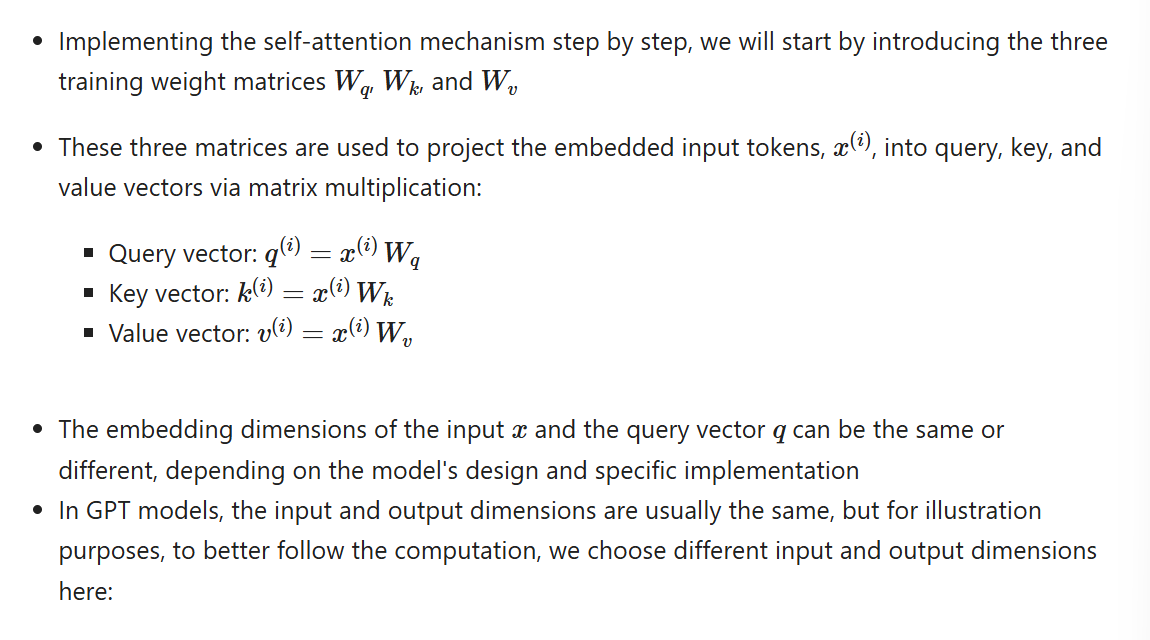

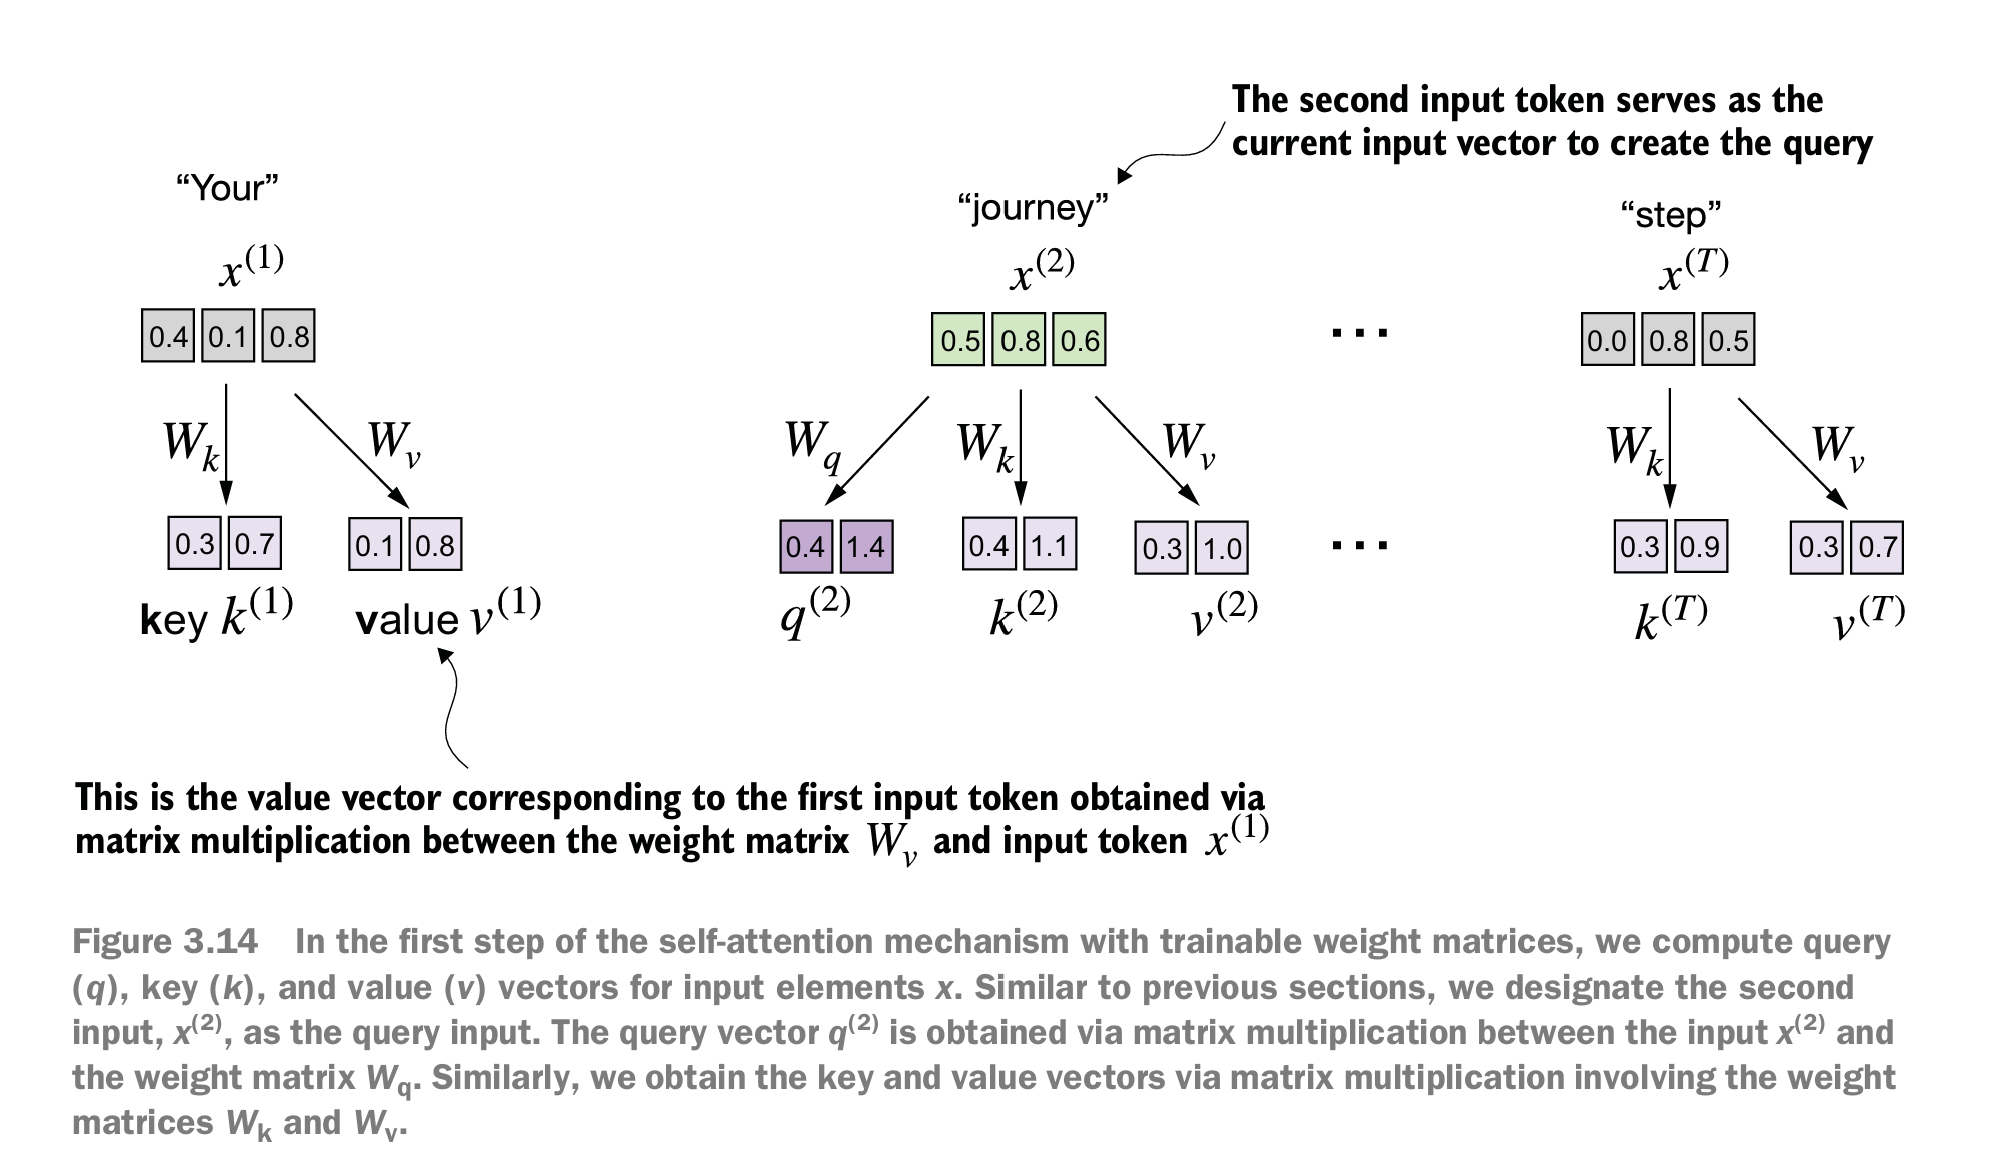

In [72]:
x_2 = inputs[1] # second input element
d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size, d=2

In [73]:
torch.manual_seed(123)

WQuery = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

WKey = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

WValue = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [74]:
query2 = x_2 @ WQuery
key2 = x_2 @ WKey
value2 = x_2 @ WValue

print(query2)

tensor([0.4306, 1.4551])


As we can see below, we successfully projected the 6 input tokens from a 3D onto a 2D embedding space:

In [75]:
keys = inputs @ WKey
values = inputs @ WValue

print("Keys.shape: ", keys.shape)
print("Values.shape: ", values.shape)

Keys.shape:  torch.Size([6, 2])
Values.shape:  torch.Size([6, 2])


In the next step, step 2, we compute the unnormalized attention scores by computing the dot product between the query and each key vector:

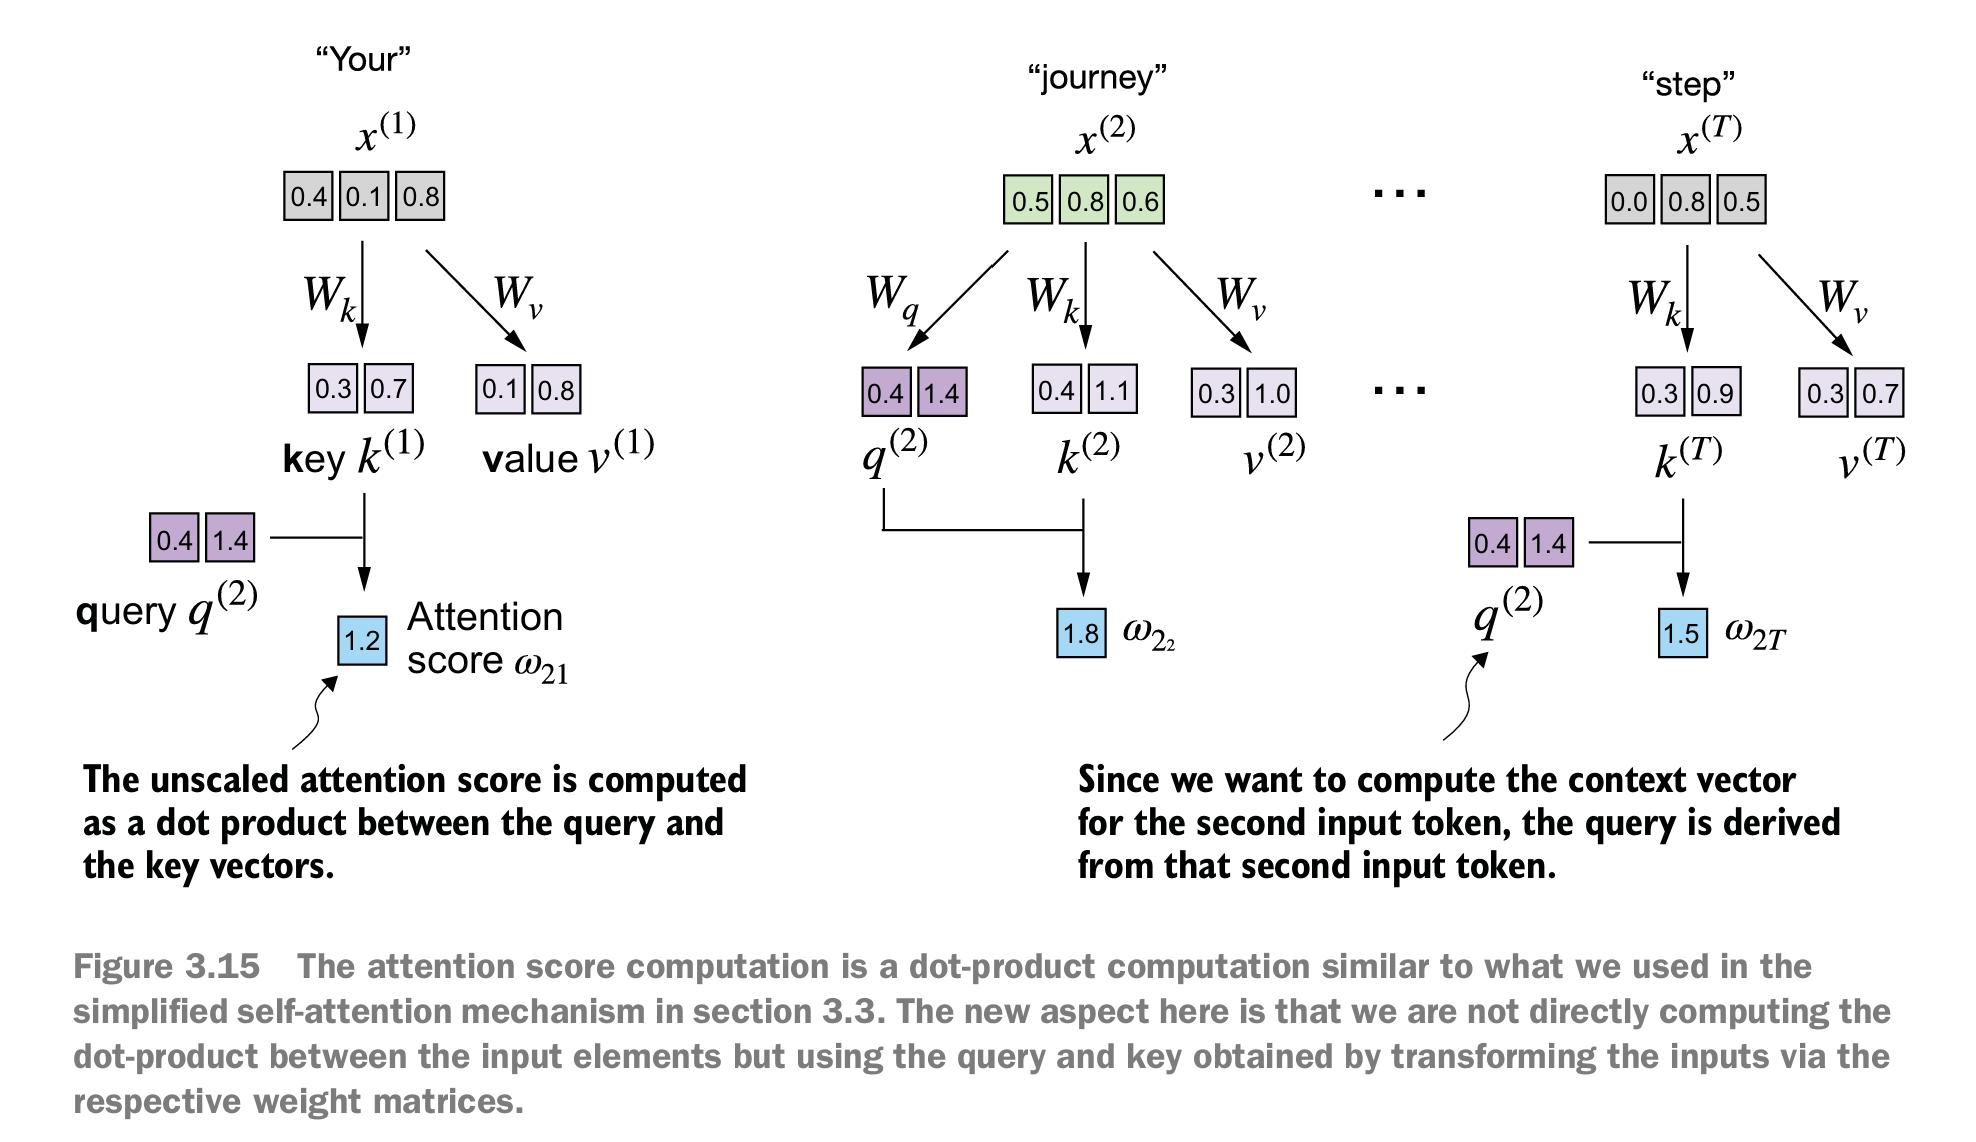

In [76]:
attenScore2 = query2 @ keys.T
print(attenScore2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


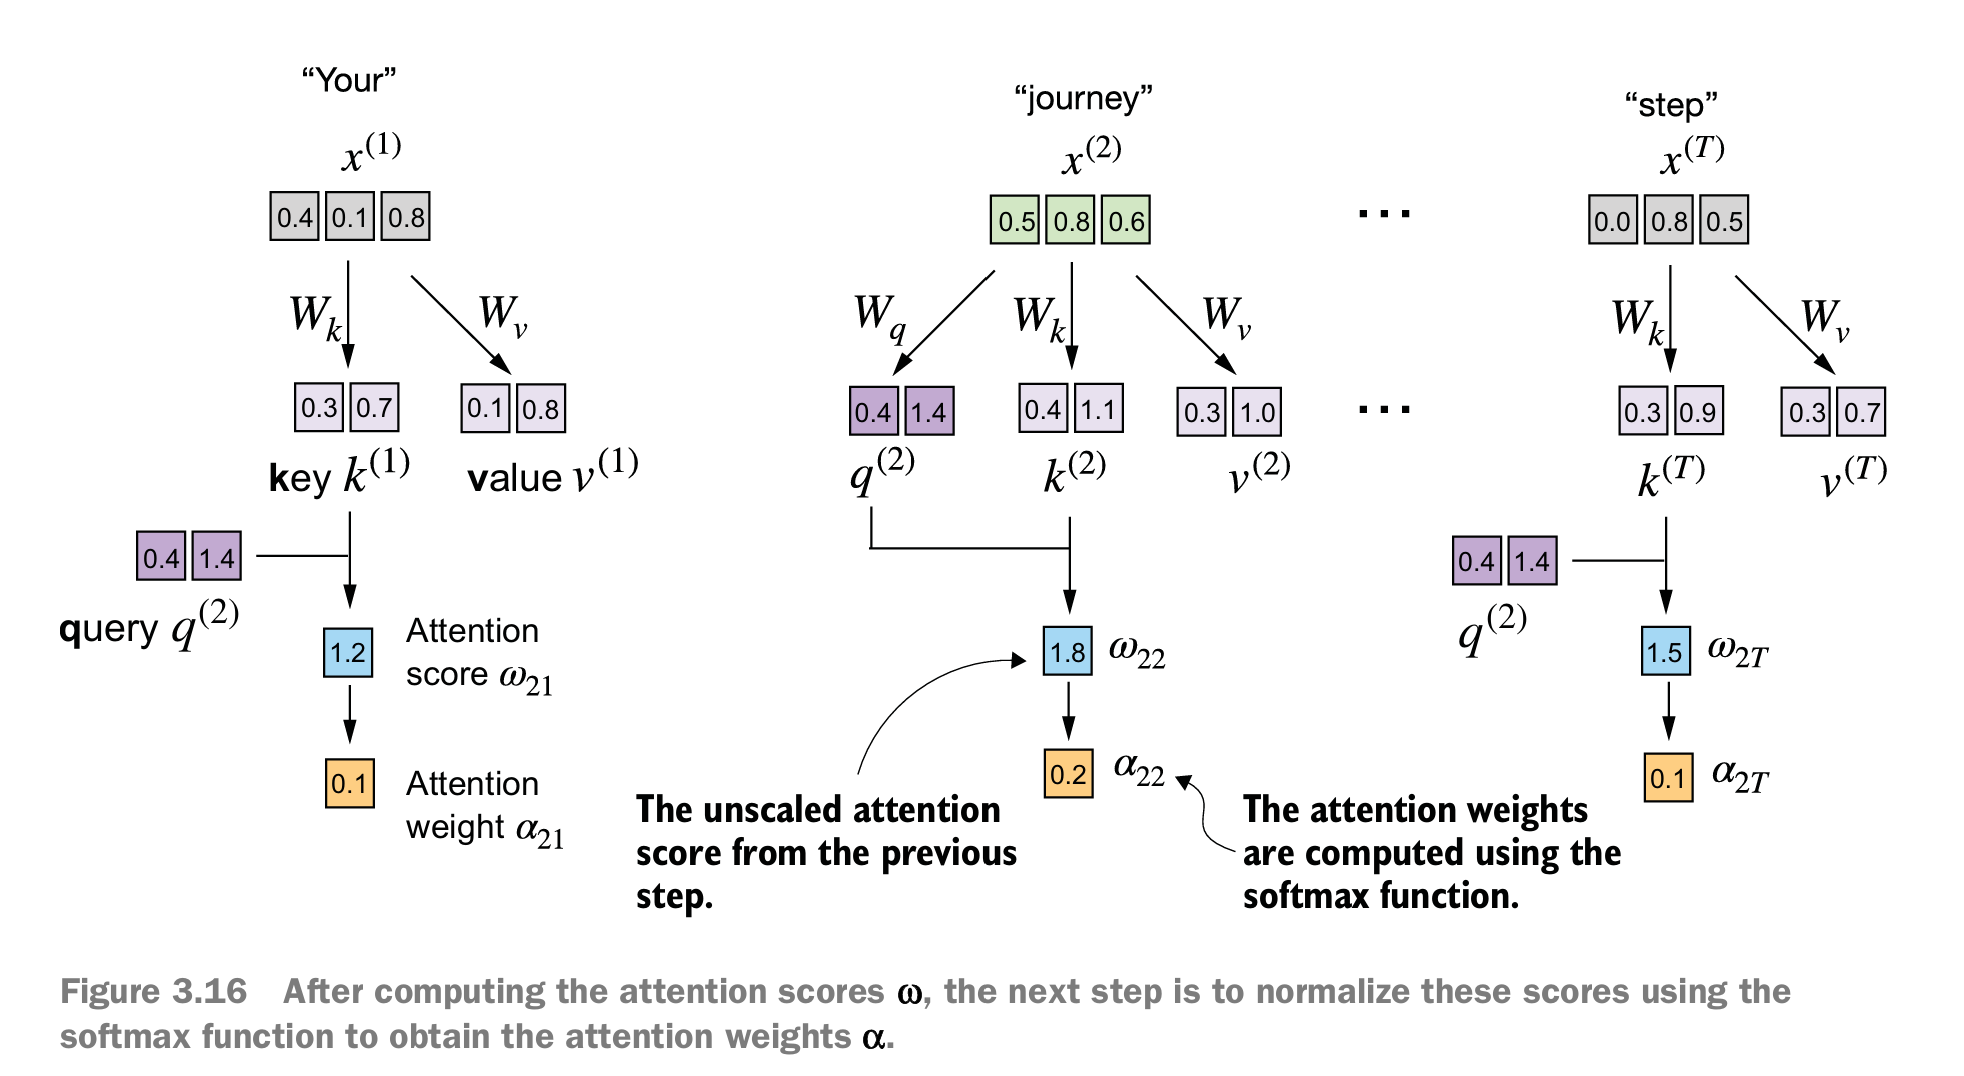

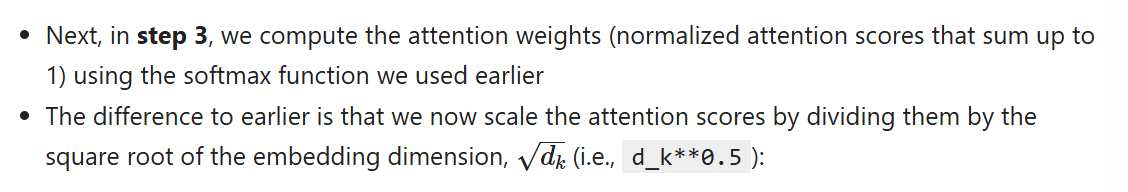

In [77]:
dk = keys.shape[1]
attenWeight = torch.softmax(attenScore2 / dk**0.5, dim=-1)

print(attenWeight)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


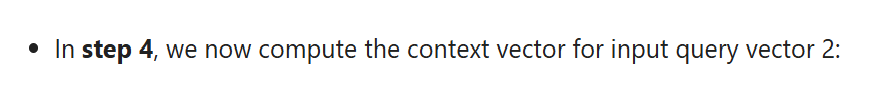

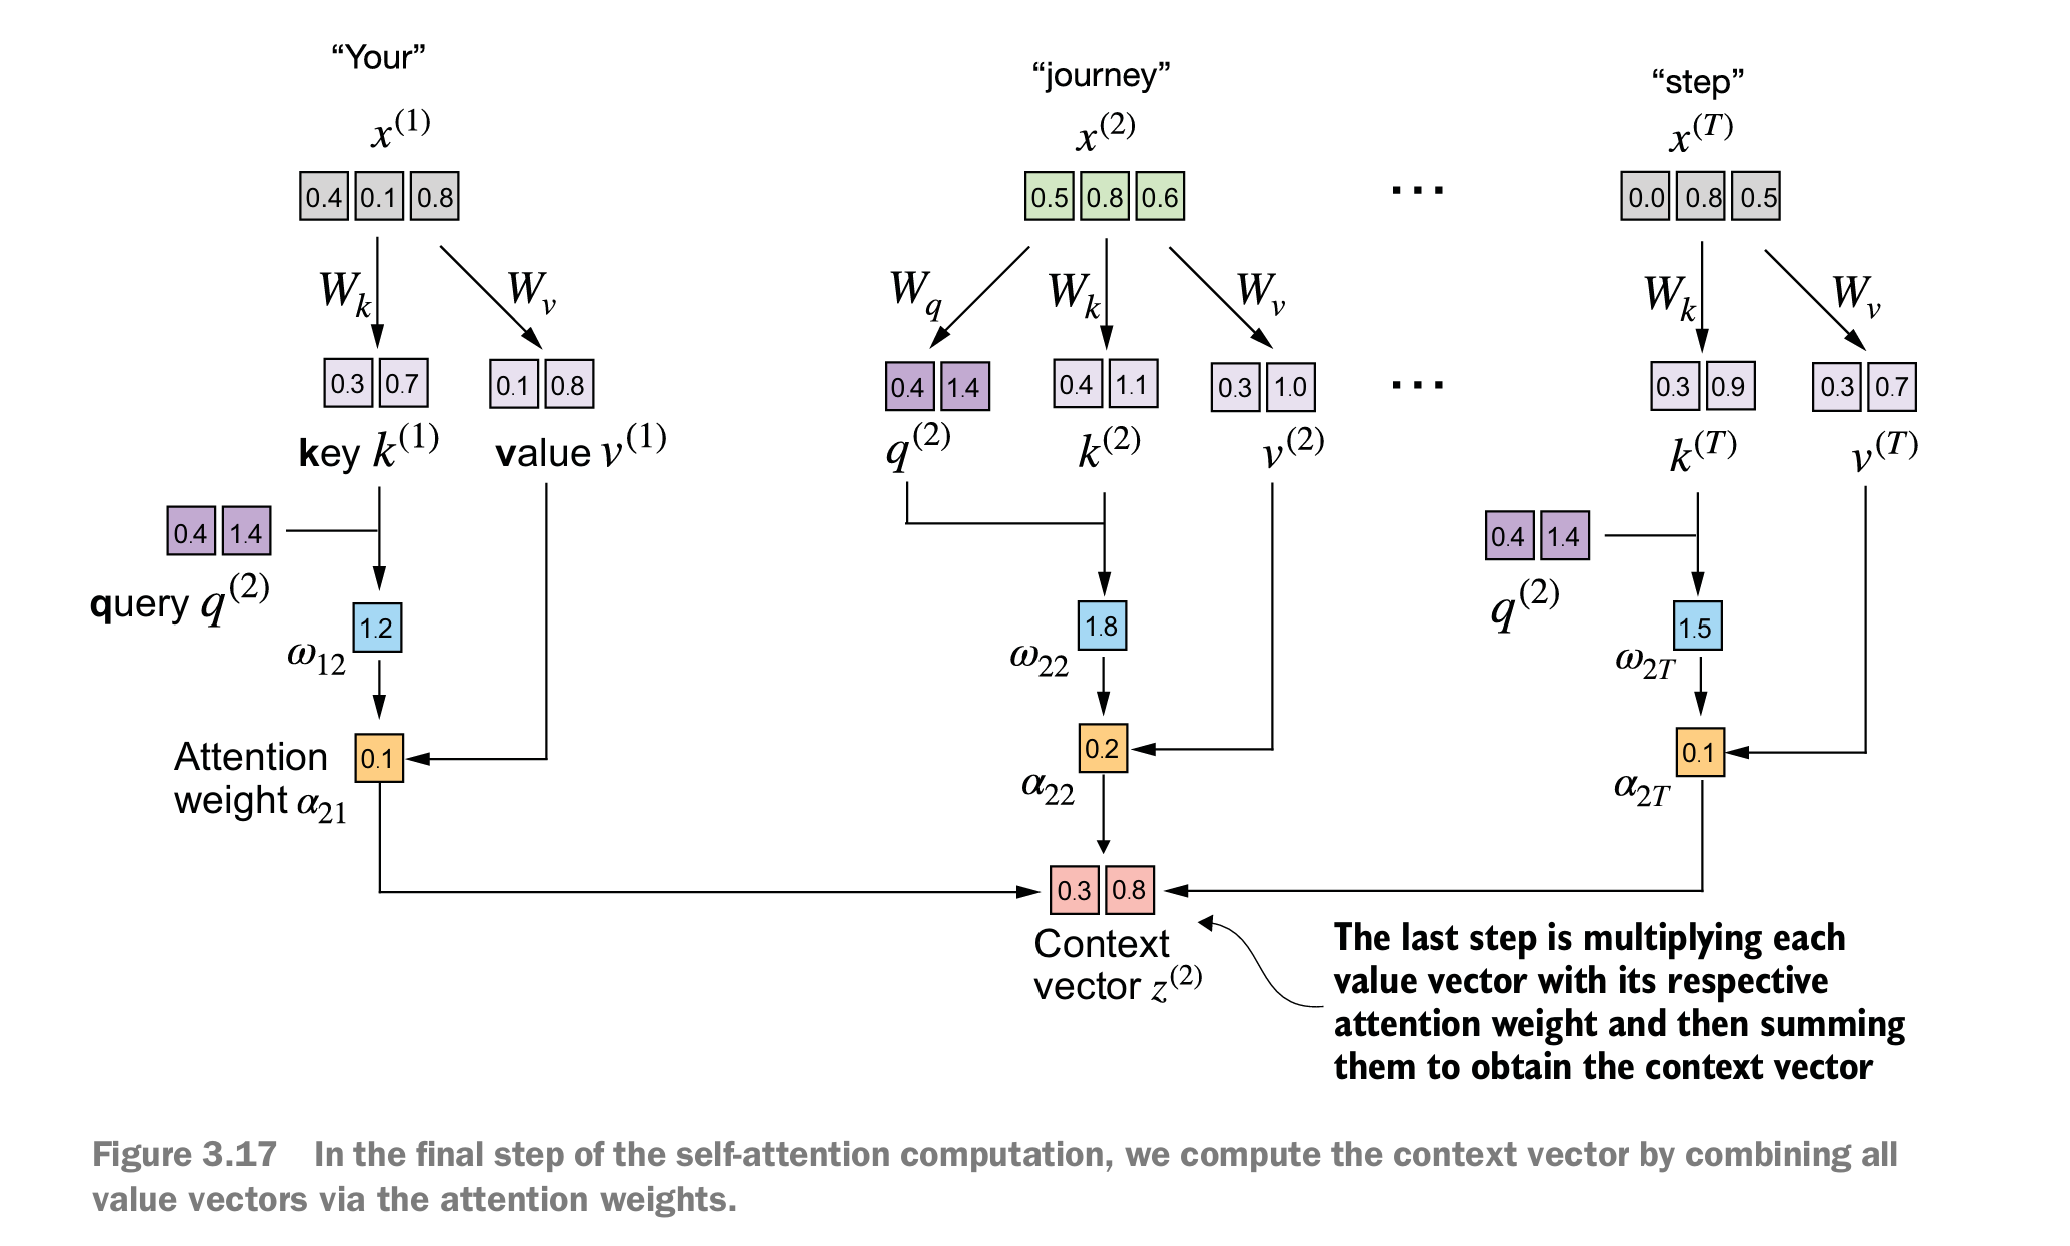

In [78]:
contextVect2 = attenWeight @ values

print(contextVect2)

tensor([0.3061, 0.8210])


### Implementing a compact SelfAttention class

Putting it all together, we can implement the self-attention mechanism as follows:

In [79]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

  def __init__(self, d_in, d_out):
    super().__init__()
    self.WQuery = nn.Parameter(torch.rand(d_in, d_out))
    self.WKey = nn.Parameter(torch.rand(d_in, d_out))
    self.WValue = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.WKey
    values = x @ self.WValue
    queries = x @ self.WQuery

    attenScore = queries @ keys.T
    attenWeight = torch.softmax(
        attenScore / keys.shape[-1] ** 0.5, dim=-1)

    contextVector = attenWeight @ values
    return contextVector


torch.manual_seed(123)
princev1 = SelfAttention_v1(d_in, d_out)
print(princev1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


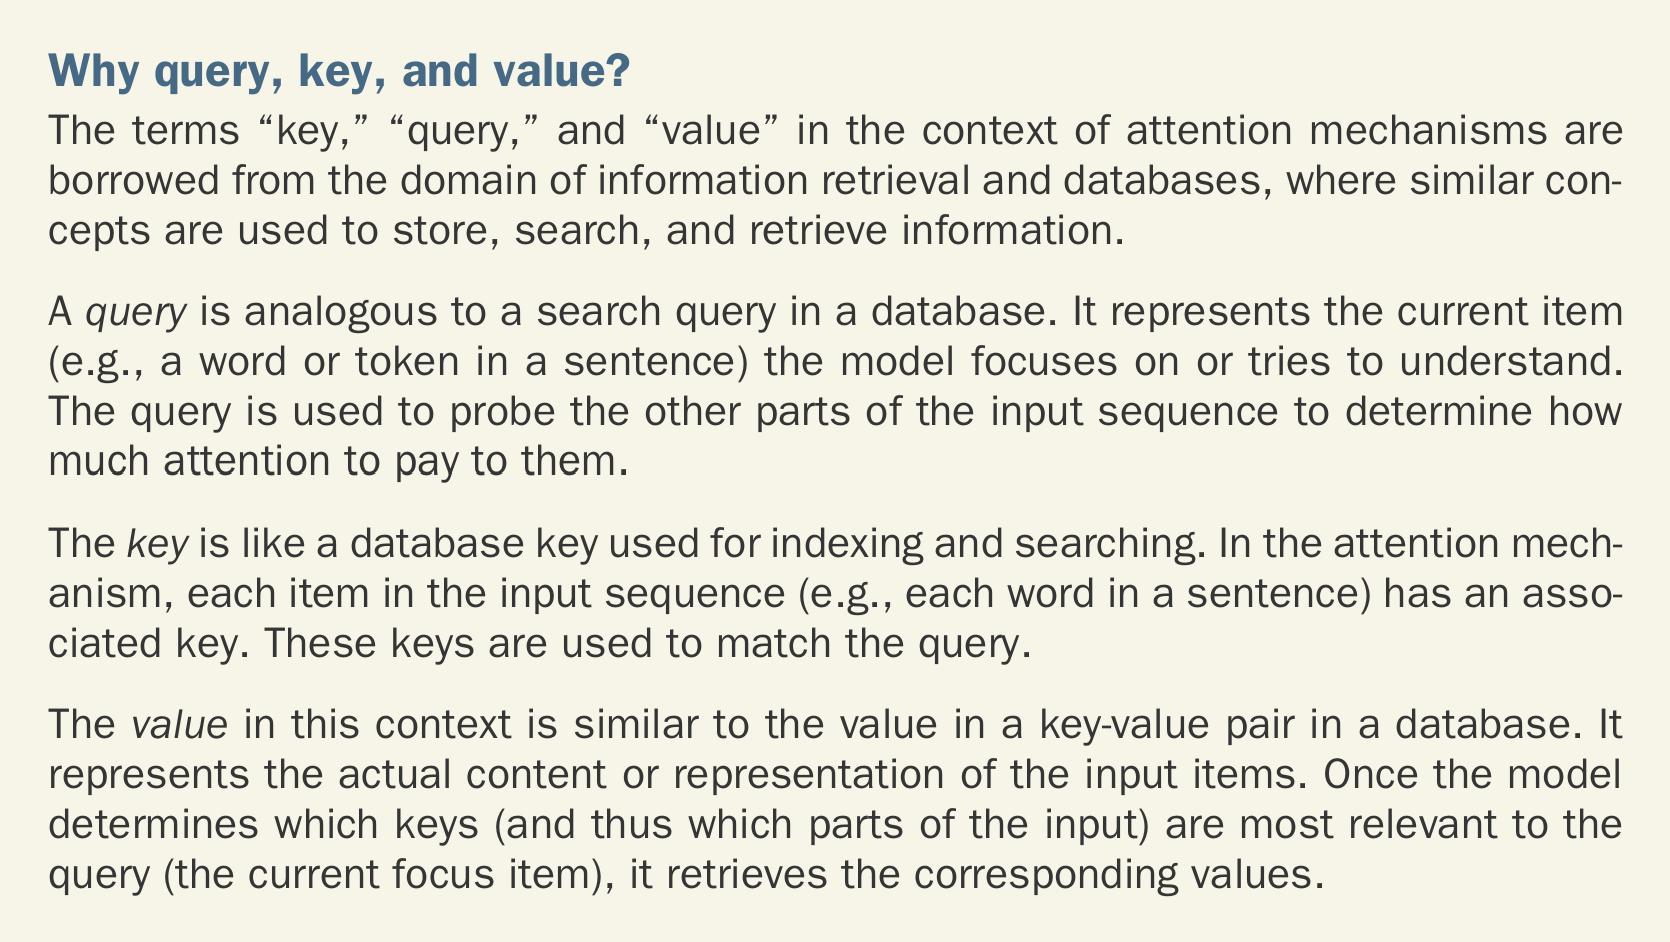

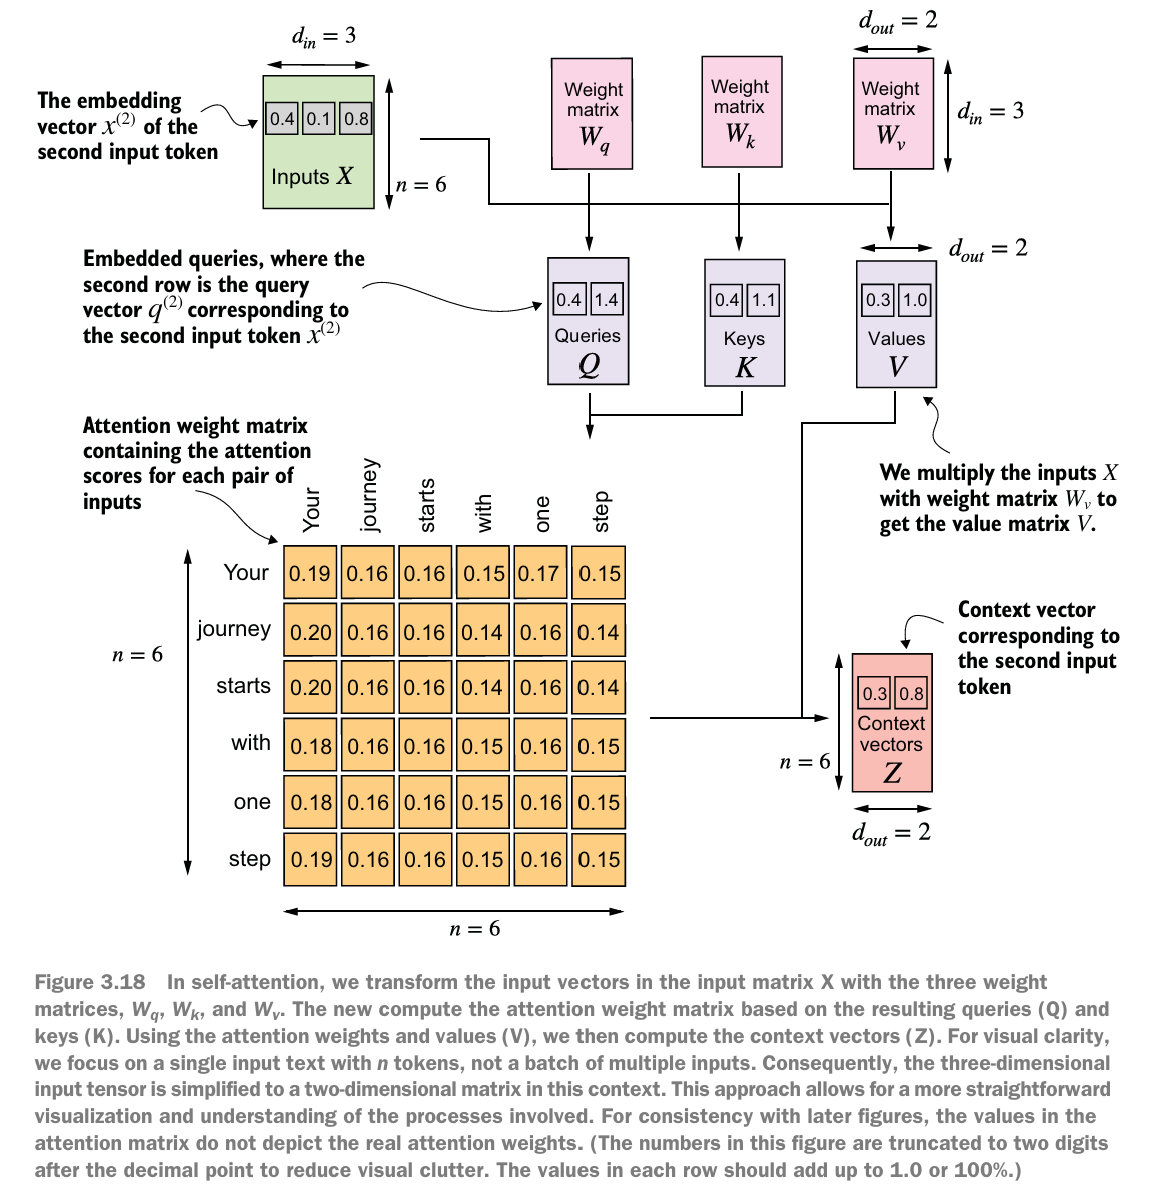

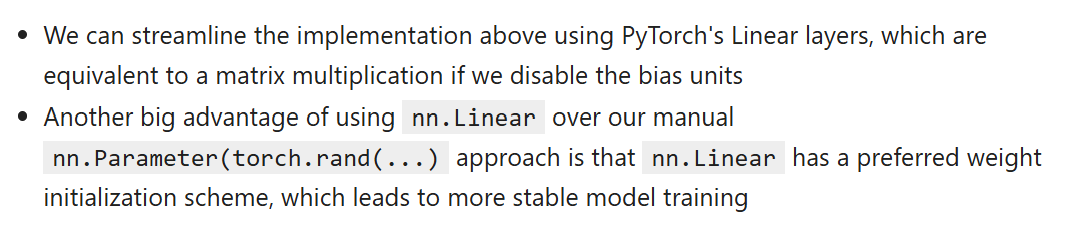

In [85]:


class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.WQuery = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.WKey = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.WValue = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.WKey(x)
    values = self.WValue(x)
    queries = self.WQuery(x)

    attenScore = queries @ keys.T
    attenWeight = torch.softmax(
        attenScore / keys.shape[-1] ** 0.5, dim=-1)

    contextVector = attenWeight @ values
    return contextVector


torch.manual_seed(789)
princev2 = SelfAttention_v2(d_in, d_out)
print(princev2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because they use different initial weights for the weight matrices